In [1]:
# ============================================================
# MARKETING CAMPAIGN OPTIMIZER — EDA
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project root
PROJECT_ROOT = Path.cwd().parent

# Processed data directory
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Processed file paths
marketing_path = PROCESSED_DIR / "marketing_ab_processed.csv"
cookie_cats_path = PROCESSED_DIR / "cookie_cats_processed.csv"

print("Project root:", PROJECT_ROOT)
print("Processed data directory:", PROCESSED_DIR)

Project root: E:\Thanuj_V\Projects\marketing_campaign_optimizer
Processed data directory: E:\Thanuj_V\Projects\marketing_campaign_optimizer\data\processed


In [2]:
# ============================================================
# LOAD PROCESSED DATASETS
# ============================================================

marketing_df = pd.read_csv(marketing_path)
cookie_cats_df = pd.read_csv(cookie_cats_path)

print("=== DATASETS LOADED ===")

print(f"Marketing A/B: {marketing_df.shape[0]:,} rows × {marketing_df.shape[1]} columns")
print(f"Cookie Cats:   {cookie_cats_df.shape[0]:,} rows × {cookie_cats_df.shape[1]} columns")

print("\nMarketing columns:")
print(marketing_df.columns.tolist())

print("\nCookie Cats columns:")
print(cookie_cats_df.columns.tolist())

=== DATASETS LOADED ===
Marketing A/B: 588,101 rows × 6 columns
Cookie Cats:   90,189 rows × 5 columns

Marketing columns:
['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']

Cookie Cats columns:
['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']


In [3]:
# ============================================================
# EXPERIMENT GROUP BALANCE
# ============================================================

group_counts = (
    marketing_df["test_group"]
    .value_counts()
    .rename_axis("test_group")
    .reset_index(name="users")
)

group_counts["percentage"] = (
    group_counts["users"] / len(marketing_df) * 100
)

print("=== MARKETING A/B GROUP BALANCE ===")
display(group_counts)

print("\nTotal users:", f"{len(marketing_df):,}")

=== MARKETING A/B GROUP BALANCE ===


,test_group,users,percentage
0,ad,564577,96.000007
1,psa,23524,3.999993



Total users: 588,101


In [4]:
# ============================================================
# COOKIE CATS EXPERIMENT BALANCE
# ============================================================

version_counts = (
    cookie_cats_df["version"]
    .value_counts()
    .rename_axis("version")
    .reset_index(name="users")
)

version_counts["percentage"] = (
    version_counts["users"] / len(cookie_cats_df) * 100
)

print("=== COOKIE CATS EXPERIMENT BALANCE ===")
display(version_counts)

print("\nTotal users:", f"{len(cookie_cats_df):,}")

=== COOKIE CATS EXPERIMENT BALANCE ===


,version,users,percentage
0,gate_40,45489,50.437415
1,gate_30,44700,49.562585



Total users: 90,189


In [5]:
# ============================================================
# BASELINE EXPERIMENT METRICS
# ============================================================

# ------------------------------------------------------------
# MARKETING A/B — CONVERSION RATE
# ------------------------------------------------------------

marketing_metrics = (
    marketing_df
    .groupby("test_group")
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

marketing_metrics["conversion_rate"] = (
    marketing_metrics["conversions"]
    / marketing_metrics["users"]
    * 100
)

print("=== MARKETING A/B CONVERSION ===")
display(marketing_metrics)


# ------------------------------------------------------------
# COOKIE CATS — RETENTION RATES
# ------------------------------------------------------------

cookie_metrics = (
    cookie_cats_df
    .groupby("version")
    .agg(
        users=("userid", "count"),
        retention_1=("retention_1", "mean"),
        retention_7=("retention_7", "mean")
    )
    .reset_index()
)

cookie_metrics["retention_1_rate"] = (
    cookie_metrics["retention_1"] * 100
)

cookie_metrics["retention_7_rate"] = (
    cookie_metrics["retention_7"] * 100
)

print("\n=== COOKIE CATS RETENTION ===")
display(cookie_metrics)

=== MARKETING A/B CONVERSION ===


,test_group,users,conversions,conversion_rate
0,ad,564577,14423,2.554656
1,psa,23524,420,1.785411



=== COOKIE CATS RETENTION ===


,version,users,retention_1,retention_7,retention_1_rate,retention_7_rate
0,gate_30,44700,0.448188,0.190201,44.818792,19.020134
1,gate_40,45489,0.442283,0.182000,44.228275,18.200004


In [6]:
# ============================================================
# ABSOLUTE DIFFERENCE AND RELATIVE LIFT
# ============================================================

# ------------------------------------------------------------
# MARKETING A/B
# ad = treatment
# psa = control
# ------------------------------------------------------------

ad_rate = marketing_metrics.loc[
    marketing_metrics["test_group"] == "ad",
    "conversion_rate"
].iloc[0]

psa_rate = marketing_metrics.loc[
    marketing_metrics["test_group"] == "psa",
    "conversion_rate"
].iloc[0]

marketing_absolute_difference = ad_rate - psa_rate

marketing_relative_lift = (
    (ad_rate - psa_rate) / psa_rate
) * 100


print("=== MARKETING A/B ===")
print(f"Ad conversion rate:       {ad_rate:.4f}%")
print(f"PSA conversion rate:     {psa_rate:.4f}%")
print(f"Absolute difference:      {marketing_absolute_difference:.4f} percentage points")
print(f"Relative lift:            {marketing_relative_lift:.2f}%")


# ------------------------------------------------------------
# COOKIE CATS
# gate_30 = control
# gate_40 = treatment
# ------------------------------------------------------------

gate30_r1 = cookie_metrics.loc[
    cookie_metrics["version"] == "gate_30",
    "retention_1_rate"
].iloc[0]

gate40_r1 = cookie_metrics.loc[
    cookie_metrics["version"] == "gate_40",
    "retention_1_rate"
].iloc[0]

gate30_r7 = cookie_metrics.loc[
    cookie_metrics["version"] == "gate_30",
    "retention_7_rate"
].iloc[0]

gate40_r7 = cookie_metrics.loc[
    cookie_metrics["version"] == "gate_40",
    "retention_7_rate"
].iloc[0]


r1_difference = gate40_r1 - gate30_r1
r1_lift = ((gate40_r1 - gate30_r1) / gate30_r1) * 100

r7_difference = gate40_r7 - gate30_r7
r7_lift = ((gate40_r7 - gate30_r7) / gate30_r7) * 100


print("\n=== COOKIE CATS ===")
print(f"Gate 30 Retention-1:      {gate30_r1:.4f}%")
print(f"Gate 40 Retention-1:      {gate40_r1:.4f}%")
print(f"Retention-1 difference:   {r1_difference:.4f} percentage points")
print(f"Retention-1 relative lift:{r1_lift:.2f}%")

print()

print(f"Gate 30 Retention-7:      {gate30_r7:.4f}%")
print(f"Gate 40 Retention-7:      {gate40_r7:.4f}%")
print(f"Retention-7 difference:   {r7_difference:.4f} percentage points")
print(f"Retention-7 relative lift:{r7_lift:.2f}%")

=== MARKETING A/B ===
Ad conversion rate:       2.5547%
PSA conversion rate:     1.7854%
Absolute difference:      0.7692 percentage points
Relative lift:            43.09%

=== COOKIE CATS ===
Gate 30 Retention-1:      44.8188%
Gate 40 Retention-1:      44.2283%
Retention-1 difference:   -0.5905 percentage points
Retention-1 relative lift:-1.32%

Gate 30 Retention-7:      19.0201%
Gate 40 Retention-7:      18.2000%
Retention-7 difference:   -0.8201 percentage points
Retention-7 relative lift:-4.31%


In [7]:
# ============================================================
# DISTRIBUTION ANALYSIS
# ============================================================

print("=== MARKETING: TOTAL ADS ===")

print(f"Mean:   {marketing_df['total_ads'].mean():.2f}")
print(f"Median: {marketing_df['total_ads'].median():.2f}")
print(f"Std:    {marketing_df['total_ads'].std():.2f}")
print(f"Min:    {marketing_df['total_ads'].min():,}")
print(f"Max:    {marketing_df['total_ads'].max():,}")

print("\nPercentiles:")
print(
    marketing_df["total_ads"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99, 0.999])
)


print("\n" + "=" * 60)
print("COOKIE CATS: SUM GAME ROUNDS")
print("=" * 60)

print(f"Mean:   {cookie_cats_df['sum_gamerounds'].mean():.2f}")
print(f"Median: {cookie_cats_df['sum_gamerounds'].median():.2f}")
print(f"Std:    {cookie_cats_df['sum_gamerounds'].std():.2f}")
print(f"Min:    {cookie_cats_df['sum_gamerounds'].min():,}")
print(f"Max:    {cookie_cats_df['sum_gamerounds'].max():,}")

print("\nPercentiles:")
print(
    cookie_cats_df["sum_gamerounds"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99, 0.999])
)

=== MARKETING: TOTAL ADS ===
Mean:   24.82
Median: 13.00
Std:    43.72
Min:    1
Max:    2,065

Percentiles:
0.500     13.0
0.750     27.0
0.900     57.0
0.950     88.0
0.990    202.0
0.999    499.9
Name: total_ads, dtype: float64

COOKIE CATS: SUM GAME ROUNDS
Mean:   51.87
Median: 16.00
Std:    195.05
Min:    0
Max:    49,854

Percentiles:
0.500      16.000
0.750      51.000
0.900     134.000
0.950     221.000
0.990     493.000
0.999    1073.624
Name: sum_gamerounds, dtype: float64


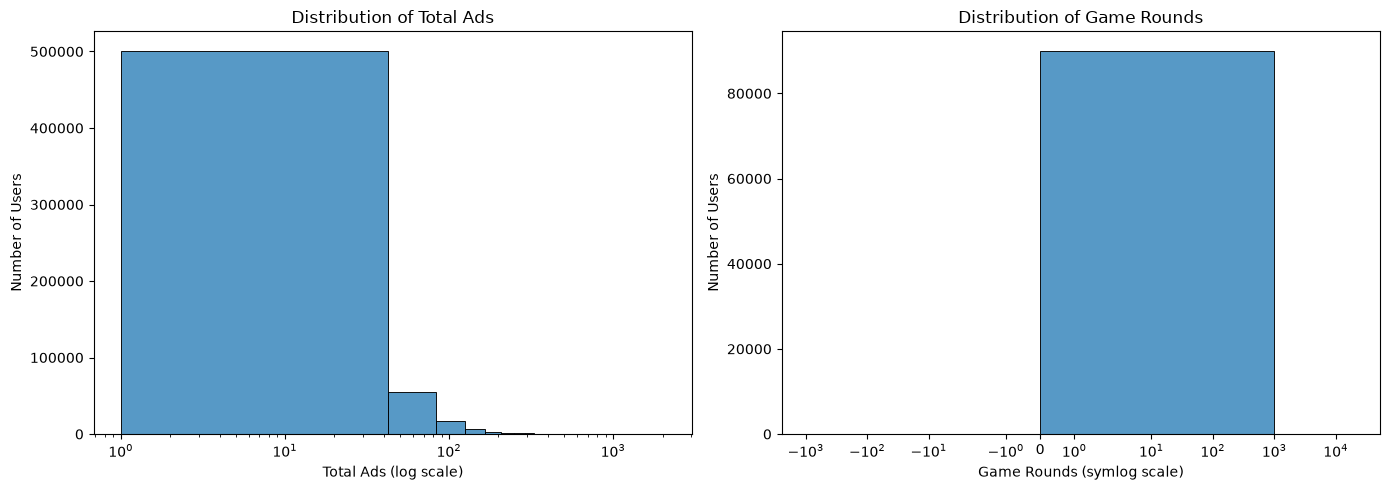

In [8]:
# ============================================================
# DISTRIBUTION VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# MARKETING — TOTAL ADS
# ------------------------------------------------------------

sns.histplot(
    marketing_df["total_ads"],
    bins=50,
    ax=axes[0]
)

axes[0].set_xscale("log")
axes[0].set_title("Distribution of Total Ads")
axes[0].set_xlabel("Total Ads (log scale)")
axes[0].set_ylabel("Number of Users")


# ------------------------------------------------------------
# COOKIE CATS — GAME ROUNDS
# ------------------------------------------------------------

sns.histplot(
    cookie_cats_df["sum_gamerounds"],
    bins=50,
    ax=axes[1]
)

axes[1].set_xscale("symlog")
axes[1].set_title("Distribution of Game Rounds")
axes[1].set_xlabel("Game Rounds (symlog scale)")
axes[1].set_ylabel("Number of Users")


plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# CONVERSION RATE BY AD EXPOSURE
# ============================================================

# Create ad-exposure buckets
marketing_df["ad_exposure_bucket"] = pd.cut(
    marketing_df["total_ads"],
    bins=[0, 5, 10, 20, 50, 100, 250, np.inf],
    labels=[
        "1-5",
        "6-10",
        "11-20",
        "21-50",
        "51-100",
        "101-250",
        "251+"
    ]
)

# Calculate users and conversions per bucket
exposure_analysis = (
    marketing_df
    .groupby("ad_exposure_bucket", observed=False)
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

# Calculate conversion rate
exposure_analysis["conversion_rate"] = (
    exposure_analysis["conversions"]
    / exposure_analysis["users"]
    * 100
)

print("=== CONVERSION RATE BY AD EXPOSURE ===")
display(exposure_analysis)

=== CONVERSION RATE BY AD EXPOSURE ===


,ad_exposure_bucket,users,conversions,conversion_rate
0,1-5,177823,449,0.252498
1,6-10,82952,409,0.493056
2,11-20,127484,1070,0.839321
3,21-50,130776,3774,2.885851
4,51-100,46002,5242,11.395157
5,101-250,19448,3322,17.081448
6,251+,3616,577,15.956858


In [10]:
# ============================================================
# AD EXPOSURE BY EXPERIMENT GROUP
# ============================================================

exposure_by_group = (
    marketing_df
    .groupby("test_group")["total_ads"]
    .agg(
        users="count",
        mean="mean",
        median="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95)
    )
    .reset_index()
)

print("=== AD EXPOSURE BY EXPERIMENT GROUP ===")
display(exposure_by_group)

=== AD EXPOSURE BY EXPERIMENT GROUP ===


,test_group,users,mean,median,p75,p90,p95
0,ad,564577,24.823365,13.0,27.0,56.0,87.00
1,psa,23524,24.761138,12.0,26.0,59.0,92.85


In [11]:
# ============================================================
# CONVERSION BY EXPERIMENT GROUP AND AD EXPOSURE
# ============================================================

conversion_by_exposure_group = (
    marketing_df
    .groupby(
        ["ad_exposure_bucket", "test_group"],
        observed=False
    )
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

conversion_by_exposure_group["conversion_rate"] = (
    conversion_by_exposure_group["conversions"]
    / conversion_by_exposure_group["users"]
    * 100
)

print("=== CONVERSION BY EXPOSURE AND EXPERIMENT GROUP ===")
display(conversion_by_exposure_group)

=== CONVERSION BY EXPOSURE AND EXPERIMENT GROUP ===


,ad_exposure_bucket,test_group,users,conversions,conversion_rate
0,1-5,ad,169962,427,0.251233
1,1-5,psa,7861,22,0.279863
2,6-10,ad,79537,386,0.485309
3,6-10,psa,3415,23,0.673499
4,11-20,ad,123334,1036,0.839995
5,11-20,psa,4150,34,0.819277
6,21-50,ad,125541,3660,2.915382
7,21-50,psa,5235,114,2.177650
8,51-100,ad,44149,5135,11.631068
9,51-100,psa,1853,107,5.774420


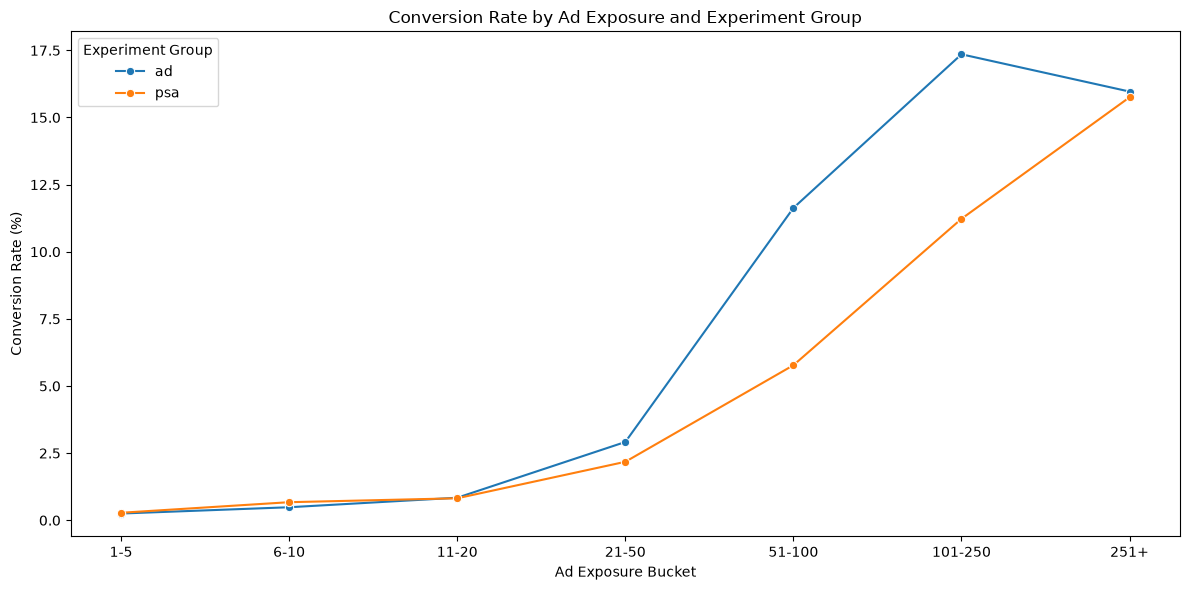

In [12]:
# ============================================================
# CONVERSION RATE BY AD EXPOSURE AND EXPERIMENT GROUP
# ============================================================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=conversion_by_exposure_group,
    x="ad_exposure_bucket",
    y="conversion_rate",
    hue="test_group",
    marker="o"
)

plt.title("Conversion Rate by Ad Exposure and Experiment Group")
plt.xlabel("Ad Exposure Bucket")
plt.ylabel("Conversion Rate (%)")
plt.legend(title="Experiment Group")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# CONVERSION RATE BY DAY OF WEEK
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_analysis = (
    marketing_df
    .groupby("most_ads_day")
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

day_analysis["conversion_rate"] = (
    day_analysis["conversions"]
    / day_analysis["users"]
    * 100
)

# Keep days in calendar order
day_analysis["most_ads_day"] = pd.Categorical(
    day_analysis["most_ads_day"],
    categories=day_order,
    ordered=True
)

day_analysis = day_analysis.sort_values("most_ads_day")

print("=== CONVERSION RATE BY DAY ===")
display(day_analysis)

=== CONVERSION RATE BY DAY ===


,most_ads_day,users,conversions,conversion_rate
1,Monday,87073,2857,3.281155
5,Tuesday,77479,2312,2.984034
6,Wednesday,80908,2018,2.494191
4,Thursday,82982,1790,2.157094
0,Friday,92608,2057,2.221190
2,Saturday,81660,1719,2.105070
3,Sunday,85391,2090,2.447565


In [14]:
# ============================================================
# CONVERSION RATE BY HOUR
# ============================================================

hour_analysis = (
    marketing_df
    .groupby("most_ads_hour")
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

hour_analysis["conversion_rate"] = (
    hour_analysis["conversions"]
    / hour_analysis["users"]
    * 100
)

hour_analysis = hour_analysis.sort_values("most_ads_hour")

print("=== CONVERSION RATE BY HOUR ===")
display(hour_analysis)

=== CONVERSION RATE BY HOUR ===


,most_ads_hour,users,conversions,conversion_rate
0,0,5536,102,1.842486
1,1,4802,62,1.291129
2,2,5333,39,0.731296
3,3,2679,28,1.045166
4,4,722,11,1.523546
5,5,765,16,2.091503
6,6,2068,46,2.224371
7,7,6405,116,1.811085
8,8,17627,344,1.951552
9,9,31004,595,1.919107


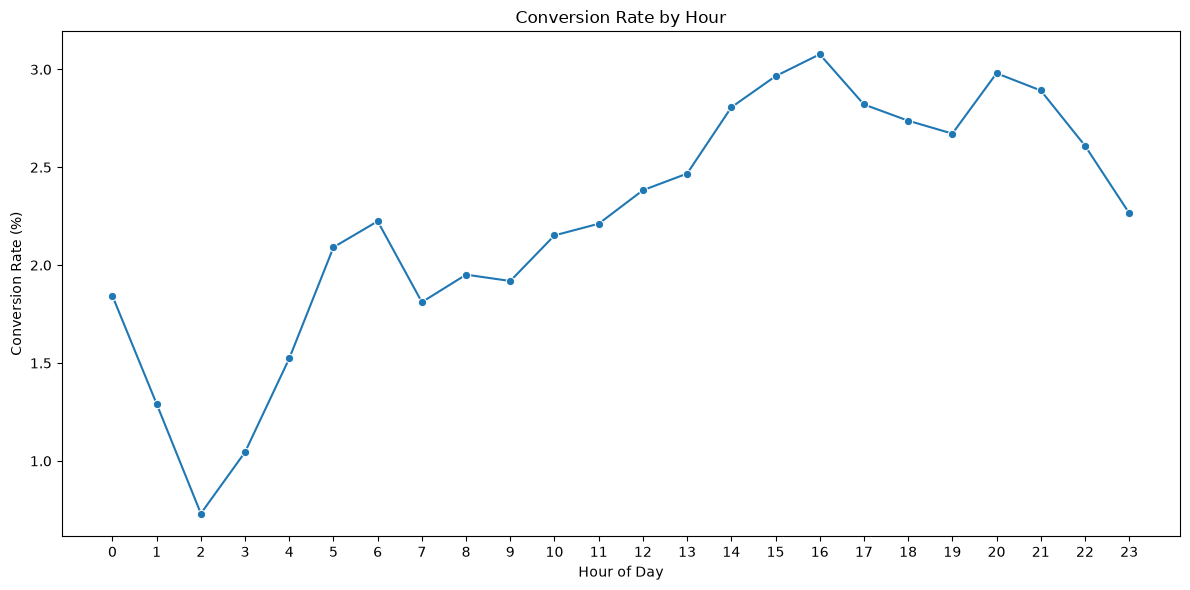

In [15]:
# ============================================================
# HOURLY CONVERSION RATE
# ============================================================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hour_analysis,
    x="most_ads_hour",
    y="conversion_rate",
    marker="o"
)

plt.title("Conversion Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Conversion Rate (%)")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# COOKIE CATS — GAME ROUND BEHAVIOR BY VERSION
# ============================================================

game_rounds_analysis = (
    cookie_cats_df
    .groupby("version")["sum_gamerounds"]
    .agg(
        users="count",
        mean="mean",
        median="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99)
    )
    .reset_index()
)

print("=== GAME ROUNDS BY EXPERIMENT VERSION ===")
display(game_rounds_analysis)

=== GAME ROUNDS BY EXPERIMENT VERSION ===


,version,users,mean,median,p75,p90,p95,p99
0,gate_30,44700,52.456264,17.0,50.0,135.0,222.0,493.00
1,gate_40,45489,51.298776,16.0,52.0,134.0,220.0,492.12


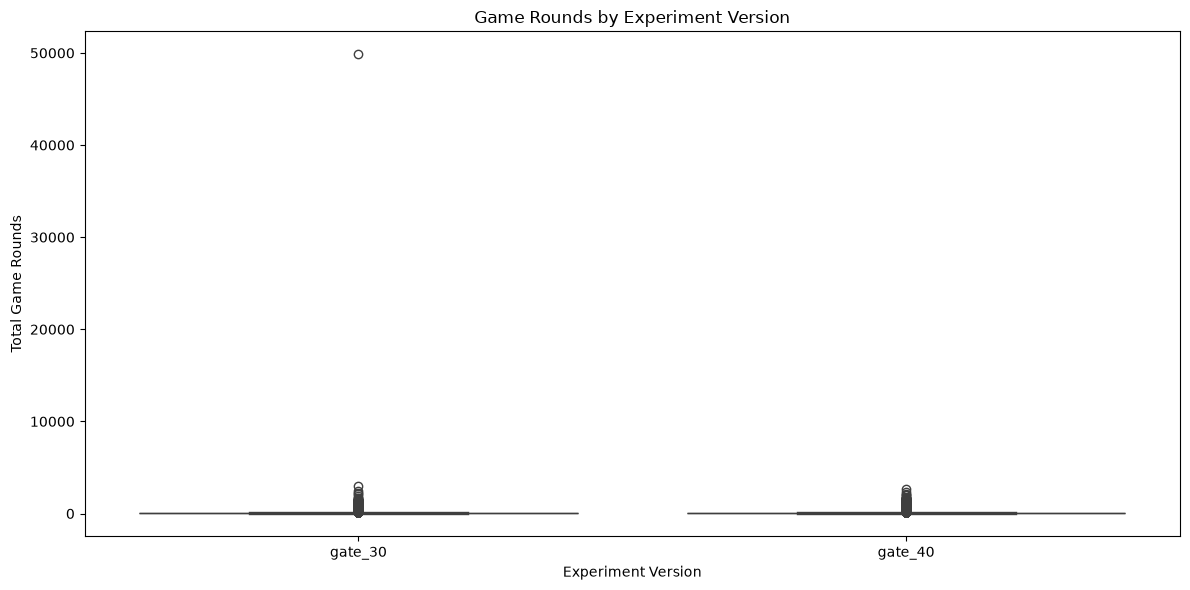

In [17]:
# ============================================================
# COOKIE CATS — GAME ROUNDS BY VERSION
# ============================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=cookie_cats_df,
    x="version",
    y="sum_gamerounds"
)

plt.title("Game Rounds by Experiment Version")
plt.xlabel("Experiment Version")
plt.ylabel("Total Game Rounds")

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# COOKIE CATS — RETENTION COUNTS
# ============================================================

retention_analysis = (
    cookie_cats_df
    .groupby("version")
    .agg(
        users=("userid", "count"),
        retained_1_day=("retention_1", "sum"),
        retained_7_day=("retention_7", "sum")
    )
    .reset_index()
)

# Calculate non-retained users
retention_analysis["not_retained_1_day"] = (
    retention_analysis["users"]
    - retention_analysis["retained_1_day"]
)

retention_analysis["not_retained_7_day"] = (
    retention_analysis["users"]
    - retention_analysis["retained_7_day"]
)

print("=== COOKIE CATS RETENTION COUNTS ===")
display(retention_analysis)

=== COOKIE CATS RETENTION COUNTS ===


,version,users,retained_1_day,retained_7_day,not_retained_1_day,not_retained_7_day
0,gate_30,44700,20034,8502,24666,36198
1,gate_40,45489,20119,8279,25370,37210


=== RETENTION RATES ===


,version,retention_1,retention_7
0,gate_30,44.818792,19.020134
1,gate_40,44.228275,18.200004


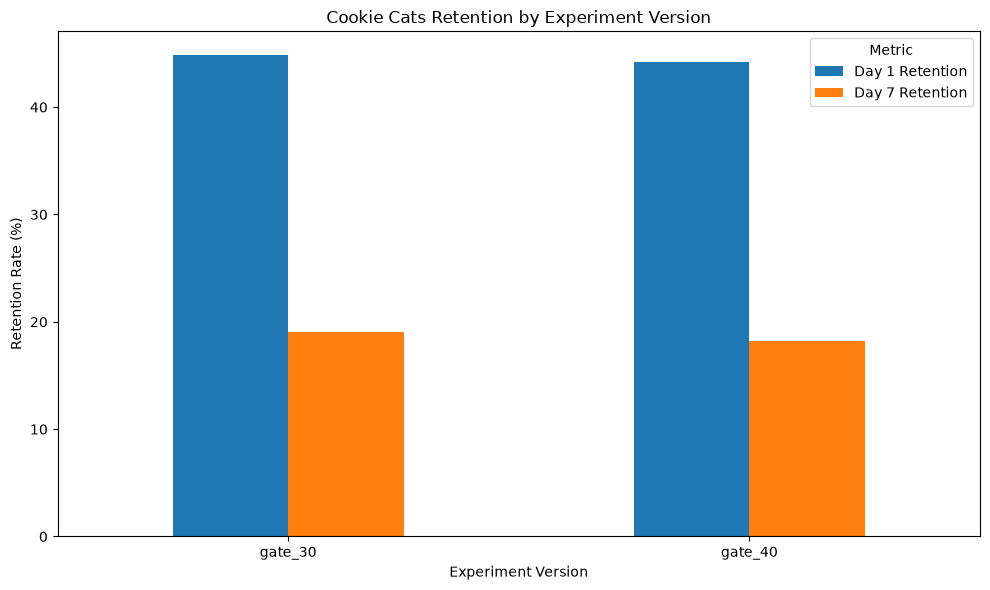

In [19]:
# ============================================================
# COOKIE CATS — RETENTION RATE VISUALIZATION
# ============================================================

retention_rates = (
    cookie_cats_df
    .groupby("version")
    .agg(
        retention_1=("retention_1", "mean"),
        retention_7=("retention_7", "mean")
    )
    .reset_index()
)

# Convert proportions to percentages
retention_rates["retention_1"] *= 100
retention_rates["retention_7"] *= 100

print("=== RETENTION RATES ===")
display(retention_rates)


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

retention_plot = retention_rates.set_index("version")[
    ["retention_1", "retention_7"]
]

retention_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cookie Cats Retention by Experiment Version")
plt.xlabel("Experiment Version")
plt.ylabel("Retention Rate (%)")
plt.xticks(rotation=0)
plt.legend(
    ["Day 1 Retention", "Day 7 Retention"],
    title="Metric"
)

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# STATISTICAL TESTING — MARKETING A/B CONVERSION
# ============================================================

from statsmodels.stats.proportion import proportions_ztest

# ------------------------------------------------------------
# Extract experiment counts
# ------------------------------------------------------------

ad_data = marketing_df[marketing_df["test_group"] == "ad"]
psa_data = marketing_df[marketing_df["test_group"] == "psa"]

ad_conversions = ad_data["converted"].sum()
psa_conversions = psa_data["converted"].sum()

ad_users = len(ad_data)
psa_users = len(psa_data)

# Conversion rates
ad_conversion_rate = ad_conversions / ad_users
psa_conversion_rate = psa_conversions / psa_users

# ------------------------------------------------------------
# Hypothesis test
# ------------------------------------------------------------

count = np.array([
    ad_conversions,
    psa_conversions
])

nobs = np.array([
    ad_users,
    psa_users
])

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="two-sided"
)

alpha = 0.05

print("=== MARKETING A/B TWO-PROPORTION TEST ===")

print("\nHypotheses:")
print("H0: Conversion rates are equal.")
print("H1: Conversion rates are different.")

print(f"\nSignificance level (alpha): {alpha}")
print(f"Ad conversion rate:  {ad_conversion_rate:.6f}")
print(f"PSA conversion rate: {psa_conversion_rate:.6f}")

print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.10f}")

if p_value < alpha:
    print("\nResult: Reject H0.")
else:
    print("\nResult: Fail to reject H0.")

=== MARKETING A/B TWO-PROPORTION TEST ===

Hypotheses:
H0: Conversion rates are equal.
H1: Conversion rates are different.

Significance level (alpha): 0.05
Ad conversion rate:  0.025547
PSA conversion rate: 0.017854

Z-statistic: 7.3701
P-value:     0.0000000000

Result: Reject H0.


In [21]:
# ============================================================
# 95% CONFIDENCE INTERVAL FOR CONVERSION RATE DIFFERENCE
# ============================================================

from statsmodels.stats.proportion import confint_proportions_2indep

# Difference defined as:
# ad conversion rate - psa conversion rate

ci_low, ci_high = confint_proportions_2indep(
    count1=ad_conversions,
    nobs1=ad_users,
    count2=psa_conversions,
    nobs2=psa_users,
    compare="diff",
    method="wald"
)

observed_difference = ad_conversion_rate - psa_conversion_rate

print("=== MARKETING A/B 95% CONFIDENCE INTERVAL ===")

print(f"Observed difference: {observed_difference:.6f}")
print(f"Observed difference: {observed_difference * 100:.4f} percentage points")

print(f"\n95% CI lower bound: {ci_low:.6f}")
print(f"95% CI upper bound: {ci_high:.6f}")

print(
    f"\n95% CI: "
    f"[{ci_low * 100:.4f}, {ci_high * 100:.4f}] percentage points"
)

=== MARKETING A/B 95% CONFIDENCE INTERVAL ===
Observed difference: 0.007692
Observed difference: 0.7692 percentage points

95% CI lower bound: 0.005951
95% CI upper bound: 0.009434

95% CI: [0.5951, 0.9434] percentage points


In [22]:
# ============================================================
# RELATIVE LIFT
# ============================================================

relative_lift = (
    (ad_conversion_rate - psa_conversion_rate)
    / psa_conversion_rate
)

# Convert CI for the absolute difference into a relative-lift CI
relative_lift_low = ci_low / psa_conversion_rate
relative_lift_high = ci_high / psa_conversion_rate

print("=== MARKETING A/B RELATIVE LIFT ===")

print(f"Relative lift: {relative_lift * 100:.2f}%")

print(
    f"95% CI for relative lift: "
    f"[{relative_lift_low * 100:.2f}%, "
    f"{relative_lift_high * 100:.2f}%]"
)

=== MARKETING A/B RELATIVE LIFT ===
Relative lift: 43.09%
95% CI for relative lift: [33.33%, 52.84%]


In [23]:
# ============================================================
# PRACTICAL IMPACT
# ============================================================

absolute_difference = ad_conversion_rate - psa_conversion_rate

additional_conversions_per_10000 = (
    absolute_difference * 10_000
)

print("=== PRACTICAL IMPACT ===")

print(
    f"Additional conversions per 10,000 users: "
    f"{additional_conversions_per_10000:.2f}"
)

print(
    f"Additional conversions per 100,000 users: "
    f"{absolute_difference * 100_000:.2f}"
)

=== PRACTICAL IMPACT ===
Additional conversions per 10,000 users: 76.92
Additional conversions per 100,000 users: 769.25


In [26]:
# ============================================================
# LOAD COOKIE CATS PROCESSED DATA
# ============================================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

cookie_cats_clean = pd.read_csv(
    PROCESSED_DIR / "cookie_cats_processed.csv"
)

print("Cookie Cats shape:", cookie_cats_clean.shape)
print("Columns:", cookie_cats_clean.columns.tolist())

Cookie Cats shape: (90189, 5)
Columns: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']


In [27]:
# ============================================================
# COOKIE CATS: RETENTION COMPARISON
# ============================================================

gate30 = cookie_cats_clean[
    cookie_cats_clean["version"] == "gate_30"
]

gate40 = cookie_cats_clean[
    cookie_cats_clean["version"] == "gate_40"
]

gate30_retention_1 = gate30["retention_1"].mean()
gate40_retention_1 = gate40["retention_1"].mean()

gate30_retention_7 = gate30["retention_7"].mean()
gate40_retention_7 = gate40["retention_7"].mean()

print("=== COOKIE CATS RETENTION COMPARISON ===")

print(
    f"Gate 30 Day-1 retention: "
    f"{gate30_retention_1 * 100:.4f}%"
)

print(
    f"Gate 40 Day-1 retention: "
    f"{gate40_retention_1 * 100:.4f}%"
)

print(
    f"Day-1 difference: "
    f"{(gate40_retention_1 - gate30_retention_1) * 100:.4f} percentage points"
)

print()

print(
    f"Gate 30 Day-7 retention: "
    f"{gate30_retention_7 * 100:.4f}%"
)

print(
    f"Gate 40 Day-7 retention: "
    f"{gate40_retention_7 * 100:.4f}%"
)

print(
    f"Day-7 difference: "
    f"{(gate40_retention_7 - gate30_retention_7) * 100:.4f} percentage points"
)

=== COOKIE CATS RETENTION COMPARISON ===
Gate 30 Day-1 retention: 44.8188%
Gate 40 Day-1 retention: 44.2283%
Day-1 difference: -0.5905 percentage points

Gate 30 Day-7 retention: 19.0201%
Gate 40 Day-7 retention: 18.2000%
Day-7 difference: -0.8201 percentage points


In [28]:
# ============================================================
# COOKIE CATS: DAY-1 RETENTION TEST
# ============================================================

from statsmodels.stats.proportion import proportions_ztest

gate30_retained_1 = gate30["retention_1"].sum()
gate40_retained_1 = gate40["retention_1"].sum()

count = [
    gate40_retained_1,
    gate30_retained_1
]

nobs = [
    len(gate40),
    len(gate30)
]

z_stat_1, p_value_1 = proportions_ztest(
    count=count,
    nobs=nobs
)

print("=== COOKIE CATS DAY-1 RETENTION TEST ===")

print("H0: Gate 40 and Gate 30 have equal Day-1 retention.")
print("H1: Gate 40 and Gate 30 have different Day-1 retention.")
print("Alpha: 0.05")

print()
print(f"Gate 40 retention: {gate40_retention_1 * 100:.4f}%")
print(f"Gate 30 retention: {gate30_retention_1 * 100:.4f}%")

print()
print(f"Z-statistic: {z_stat_1:.4f}")
print(f"P-value: {p_value_1:.10f}")

if p_value_1 < 0.05:
    print("Result: Reject H0")
else:
    print("Result: Fail to reject H0")

=== COOKIE CATS DAY-1 RETENTION TEST ===
H0: Gate 40 and Gate 30 have equal Day-1 retention.
H1: Gate 40 and Gate 30 have different Day-1 retention.
Alpha: 0.05

Gate 40 retention: 44.2283%
Gate 30 retention: 44.8188%

Z-statistic: -1.7841
P-value: 0.0744096553
Result: Fail to reject H0


In [29]:
# ============================================================
# COOKIE CATS: DAY-7 RETENTION TEST
# ============================================================

gate30_retained_7 = gate30["retention_7"].sum()
gate40_retained_7 = gate40["retention_7"].sum()

count = [
    gate40_retained_7,
    gate30_retained_7
]

nobs = [
    len(gate40),
    len(gate30)
]

z_stat_7, p_value_7 = proportions_ztest(
    count=count,
    nobs=nobs
)

print("=== COOKIE CATS DAY-7 RETENTION TEST ===")

print("H0: Gate 40 and Gate 30 have equal Day-7 retention.")
print("H1: Gate 40 and Gate 30 have different Day-7 retention.")
print("Alpha: 0.05")

print()
print(f"Gate 40 retention: {gate40_retention_7 * 100:.4f}%")
print(f"Gate 30 retention: {gate30_retention_7 * 100:.4f}%")

print()
print(f"Z-statistic: {z_stat_7:.4f}")
print(f"P-value: {p_value_7:.10f}")

if p_value_7 < 0.05:
    print("Result: Reject H0")
else:
    print("Result: Fail to reject H0")

=== COOKIE CATS DAY-7 RETENTION TEST ===
H0: Gate 40 and Gate 30 have equal Day-7 retention.
H1: Gate 40 and Gate 30 have different Day-7 retention.
Alpha: 0.05

Gate 40 retention: 18.2000%
Gate 30 retention: 19.0201%

Z-statistic: -3.1644
P-value: 0.0015542500
Result: Reject H0


In [30]:
# ============================================================
# COOKIE CATS: DAY-7 RELATIVE LIFT
# ============================================================

relative_lift_7 = (
    (gate40_retention_7 - gate30_retention_7)
    / gate30_retention_7
)

print("=== COOKIE CATS DAY-7 RELATIVE LIFT ===")

print(
    f"Relative lift: "
    f"{relative_lift_7 * 100:.2f}%"
)

=== COOKIE CATS DAY-7 RELATIVE LIFT ===
Relative lift: -4.31%


In [31]:
# ============================================================
# COOKIE CATS: DAY-7 95% CONFIDENCE INTERVAL
# ============================================================

from statsmodels.stats.proportion import confint_proportions_2indep

ci_low_7, ci_high_7 = confint_proportions_2indep(
    count1=gate40_retained_7,
    nobs1=len(gate40),
    count2=gate30_retained_7,
    nobs2=len(gate30),
    compare="diff",
    method="wald"
)

observed_difference_7 = (
    gate40_retention_7 - gate30_retention_7
)

print("=== COOKIE CATS DAY-7 95% CONFIDENCE INTERVAL ===")

print(
    f"Observed difference: "
    f"{observed_difference_7 * 100:.4f} percentage points"
)

print(
    f"95% CI: "
    f"[{ci_low_7 * 100:.4f}, "
    f"{ci_high_7 * 100:.4f}] percentage points"
)

=== COOKIE CATS DAY-7 95% CONFIDENCE INTERVAL ===
Observed difference: -0.8201 percentage points
95% CI: [-1.3282, -0.3121] percentage points


In [32]:
# ============================================================
# COOKIE CATS: DAY-1 95% CONFIDENCE INTERVAL
# ============================================================

ci_low_1, ci_high_1 = confint_proportions_2indep(
    count1=gate40_retained_1,
    nobs1=len(gate40),
    count2=gate30_retained_1,
    nobs2=len(gate30),
    compare="diff",
    method="wald"
)

observed_difference_1 = (
    gate40_retention_1 - gate30_retention_1
)

print("=== COOKIE CATS DAY-1 95% CONFIDENCE INTERVAL ===")

print(
    f"Observed difference: "
    f"{observed_difference_1 * 100:.4f} percentage points"
)

print(
    f"95% CI: "
    f"[{ci_low_1 * 100:.4f}, "
    f"{ci_high_1 * 100:.4f}] percentage points"
)

=== COOKIE CATS DAY-1 95% CONFIDENCE INTERVAL ===
Observed difference: -0.5905 percentage points
95% CI: [-1.2392, 0.0582] percentage points


In [33]:
# ============================================================
# COOKIE CATS: DAY-1 RELATIVE LIFT
# ============================================================

relative_lift_1 = (
    (gate40_retention_1 - gate30_retention_1)
    / gate30_retention_1
)

print("=== COOKIE CATS DAY-1 RELATIVE LIFT ===")

print(
    f"Relative lift: "
    f"{relative_lift_1 * 100:.2f}%"
)

=== COOKIE CATS DAY-1 RELATIVE LIFT ===
Relative lift: -1.32%


In [34]:
# ============================================================
# STATISTICAL SUMMARY
# ============================================================

summary = pd.DataFrame([
    {
        "experiment": "Marketing A/B",
        "metric": "Conversion Rate",
        "control": "psa",
        "treatment": "ad",
        "control_rate": psa_conversion_rate,
        "treatment_rate": ad_conversion_rate,
        "absolute_difference": ad_conversion_rate - psa_conversion_rate,
        "relative_lift": relative_lift,
        "p_value": p_value,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "decision": "Reject H0" if p_value < 0.05 else "Fail to reject H0"
    },
    {
        "experiment": "Cookie Cats",
        "metric": "Day-1 Retention",
        "control": "gate_30",
        "treatment": "gate_40",
        "control_rate": gate30_retention_1,
        "treatment_rate": gate40_retention_1,
        "absolute_difference": observed_difference_1,
        "relative_lift": relative_lift_1,
        "p_value": p_value_1,
        "ci_low": ci_low_1,
        "ci_high": ci_high_1,
        "decision": "Reject H0" if p_value_1 < 0.05 else "Fail to reject H0"
    },
    {
        "experiment": "Cookie Cats",
        "metric": "Day-7 Retention",
        "control": "gate_30",
        "treatment": "gate_40",
        "control_rate": gate30_retention_7,
        "treatment_rate": gate40_retention_7,
        "absolute_difference": observed_difference_7,
        "relative_lift": relative_lift_7,
        "p_value": p_value_7,
        "ci_low": ci_low_7,
        "ci_high": ci_high_7,
        "decision": "Reject H0" if p_value_7 < 0.05 else "Fail to reject H0"
    }
])

display(summary)

,experiment,metric,control,treatment,control_rate,treatment_rate,absolute_difference,relative_lift,p_value,ci_low,ci_high,decision
0,Marketing A/B,Conversion Rate,psa,ad,0.017854,0.025547,0.007692,0.430851,1.705281e-13,0.005951,0.009434,Reject H0
1,Cookie Cats,Day-1 Retention,gate_30,gate_40,0.448188,0.442283,-0.005905,-0.013176,7.440966e-02,-0.012392,0.000582,Fail to reject H0
2,Cookie Cats,Day-7 Retention,gate_30,gate_40,0.190201,0.182000,-0.008201,-0.043119,1.554250e-03,-0.013282,-0.003121,Reject H0


In [35]:
# ============================================================
# POWER & SAMPLE SIZE: TWO-PROPORTION TEST
# ============================================================

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Baseline conversion rate
baseline_rate = psa_conversion_rate

# Minimum Detectable Effect (MDE)
# Example: detect a 20% relative improvement
mde_relative = 0.20

# Treatment rate implied by the MDE
target_rate = baseline_rate * (1 + mde_relative)

# Convert rates into Cohen's h effect size
effect_size = proportion_effectsize(
    baseline_rate,
    target_rate
)

# Calculate required sample size per group
power_analysis = NormalIndPower()

required_sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.80,
    ratio=1.0,
    alternative="two-sided"
)

print("=== POWER & SAMPLE SIZE CALCULATION ===")

print(f"Baseline conversion rate: {baseline_rate * 100:.4f}%")
print(f"Relative MDE: {mde_relative * 100:.0f}%")
print(f"Target conversion rate: {target_rate * 100:.4f}%")
print(f"Required sample size per group: {required_sample_size:.0f}")
print(f"Total required sample size: {required_sample_size * 2:.0f}")

=== POWER & SAMPLE SIZE CALCULATION ===
Baseline conversion rate: 1.7854%
Relative MDE: 20%
Target conversion rate: 2.1425%
Required sample size per group: 23655
Total required sample size: 47311
